<a href="https://colab.research.google.com/github/Gnissan-BIA/Assignments/blob/main/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay


In [6]:
# Load dataset
df = pd.read_csv("/content/Titanic-Dataset.csv")

# Display the first 5 rows
print(df.head())

# Check for null values and duplicates
print(df.isnull().sum())
print(df.duplicated().sum())

df = df.drop_duplicates()

# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

if "Cabin" in df.columns:
    df = df.drop(columns=["Cabin"])

le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])


# Split data into train and test
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Pa

# EDA

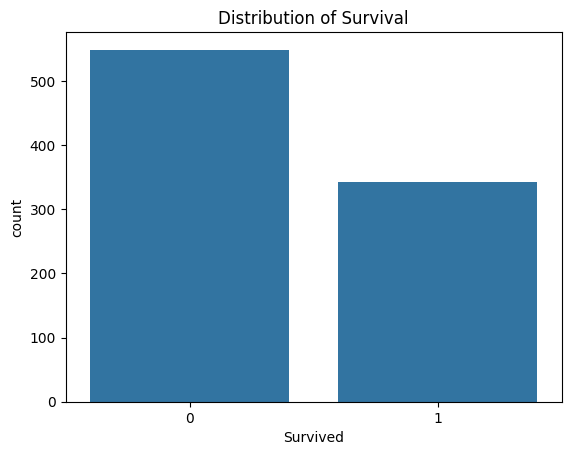

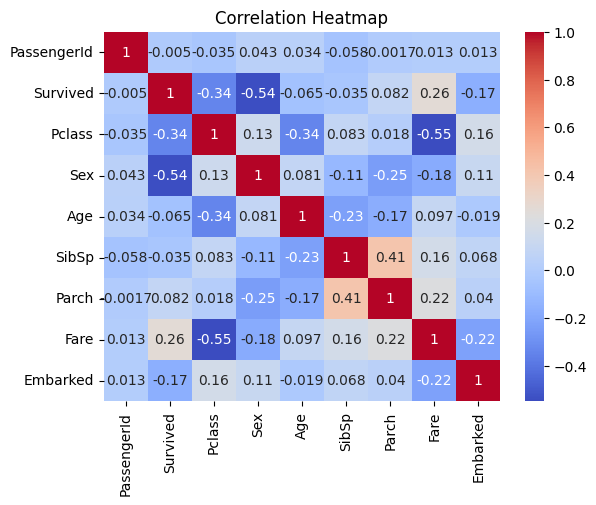

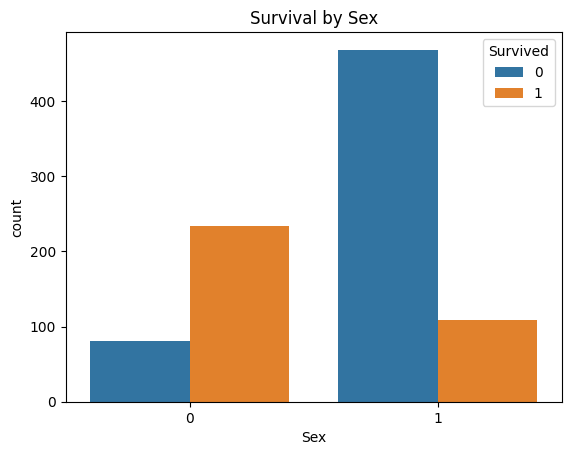

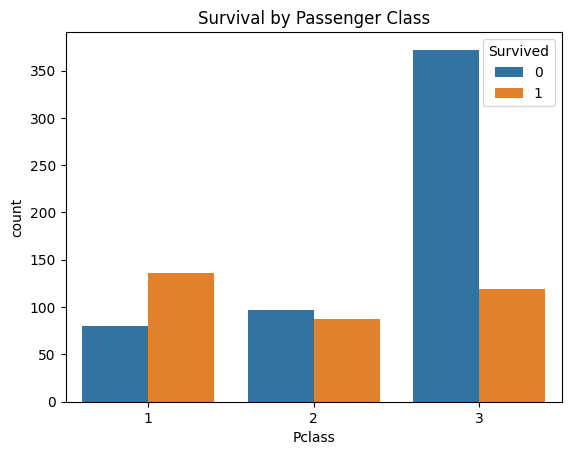

In [7]:

# Plot distribution of Survival
sns.countplot(x="Survived", data=df)
plt.title("Distribution of Survival")
plt.show()

# Plot relationship between variables
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Plot survival by sex
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Sex")
plt.show()

# Plot survival by Passenger Class
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

#Model Implementation

In [8]:
# Initialize the models
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(random_state=42)

# train the models
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Make the prediction
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

# Predict class probability
lr_proba = lr.predict_proba(X_test)[:, 1]
rf_proba = rf.predict_proba(X_test)[:, 1]

#Model Evaluation

In [9]:

# Function to evaluate models
def evaluate_model(name, y_test, y_pred, y_proba):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))

evaluate_model("Logistic Regression", y_test, lr_pred, lr_proba)
evaluate_model("Random Forest", y_test, rf_pred, rf_proba)


Logistic Regression
Accuracy: 0.8044692737430168
Precision: 0.7931034482758621
Recall: 0.6666666666666666
F1-score: 0.7244094488188977
ROC-AUC: 0.852042160737813

Random Forest
Accuracy: 0.8268156424581006
Precision: 0.8064516129032258
Recall: 0.7246376811594203
F1-score: 0.7633587786259542
ROC-AUC: 0.827733860342556


#Model Performance

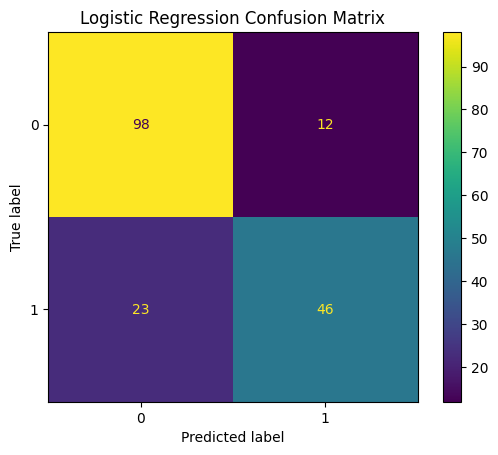

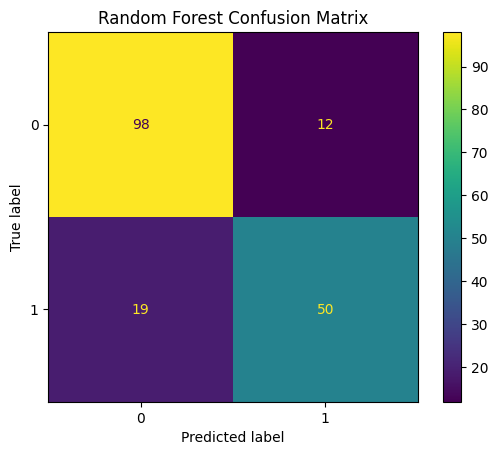

In [10]:

# Confusion matrix Logistic Regression
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# confusion matrix Random Forest
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

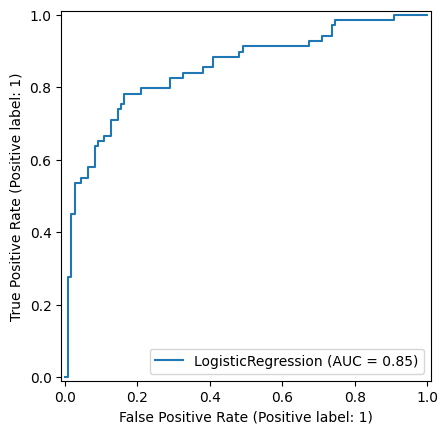

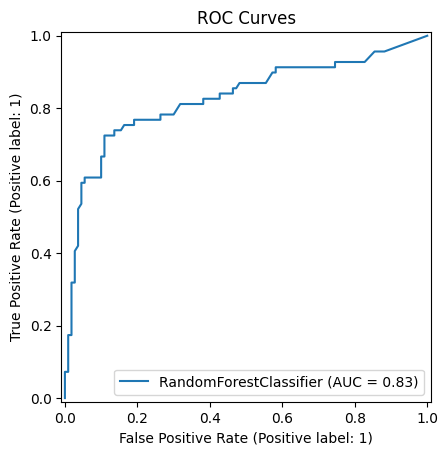

In [11]:
RocCurveDisplay.from_estimator(lr, X_test, y_test)
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("ROC Curves")
plt.show()